In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [5]:
df = pd.read_csv('data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Preparing the X and y feature

In [9]:
df.rename(
    columns={"race/ethnicity": "race_or_ethnicity", 
             "parental level of education": "parental_level_of_education",
             "test preparation course":"test_preparation_course",
             "math score": "math_score",
             "reading score": "reading_score",
             "writing score": "writing_score"}, inplace=True)

In [10]:
X = df.drop(['math_score'], axis = 1)
y = df['math_score']

In [15]:
X.head()

,gender,race_or_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [13]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [23]:
# Create Column Tranformer with 3 types of transformers
num_features = X.select_dtypes(include='number').columns
cat_feature = X.select_dtypes(include=['object','string']).columns
num_features, cat_feature

(Index(['reading_score', 'writing_score'], dtype='str'),
 Index(['gender', 'race_or_ethnicity', 'parental_level_of_education', 'lunch',
        'test_preparation_course'],
       dtype='str'))

In [24]:
numeric_transformer = StandardScaler()
one_hot_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", one_hot_transformer, cat_feature),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [25]:
X.head()

,gender,race_or_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [26]:
X = preprocessor.fit_transform(X)

In [28]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [29]:
X.shape

(1000, 19)

In [31]:
# Separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [43]:
# Evaluation model with all the metrics after model training
def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    rmse = root_mean_squared_error(true, predicted)
    r2_square = r2_score(true, predicted)
    return mse, mae, rmse, r2_square

In [45]:
# Model List for training
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBoost Regressor": XGBRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False)
}

model_list = []
r2_list = []

for model_name, model in models.items():

    # Training the model
    model.fit(X_train, y_train)

    # Making predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate the training dataset
    train_mse, train_mae, train_rmse, train_r2_square = evaluate_model(
        y_train, y_train_pred
    )

    # Evaluate the test dataset
    test_mse, test_mae, test_rmse, test_r2_square = evaluate_model(
        y_test, y_test_pred
    )

    print(f"\n{'=' * 50}")
    print(f"Model: {model_name}")
    print(f"{'=' * 50}")

    print("Model performance for Training set")
    print("- Mean Squared Error: {:.4f}".format(train_mse))
    print("- Root Mean Squared Error: {:.4f}".format(train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(train_mae))
    print("- R2 Score: {:.4f}".format(train_r2_square))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- Mean Squared Error: {:.4f}".format(test_mse))
    print("- Root Mean Squared Error: {:.4f}".format(test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(test_mae))
    print("- R2 Score: {:.4f}".format(test_r2_square))

    model_list.append(model_name)
    r2_list.append(test_r2_square)



Model: Linear Regression
Model performance for Training set
- Mean Squared Error: 28.3349
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Mean Squared Error: 29.0952
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804

Model: Lasso
Model performance for Training set
- Mean Squared Error: 43.4784
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Mean Squared Error: 42.5064
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253

Model: Ridge
Model performance for Training set
- Mean Squared Error: 28.3378
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Mean Squared Error: 29.0563
- Root Mean Squared Error: 5.3904
- Mean Absolut

In [ ]:
results = pd.DataFrame({
    "Model": model_list,
    "R2 Score": r2_list
})
results = results.sort_values(by="R2 Score", ascending=False)

In [47]:
results

,Model,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.880433
8,CatBoost Regressor,0.851632
5,Random Forest Regressor,0.851608
7,AdaBoost Regressor,0.848829
6,XGBoost Regressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree Regressor,0.726081


### Linear Regression (Ridge)

In [60]:
lin_model = Ridge(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(f"Accuracy of the model is {score:.2f}%")

Accuracy of the model is 88.06%


### Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

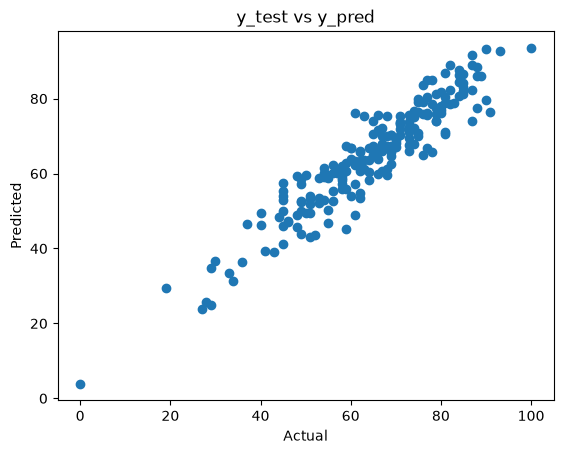

In [62]:
plt.scatter(y_test, y_pred)
plt.title('y_test vs y_pred')
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math_score'>

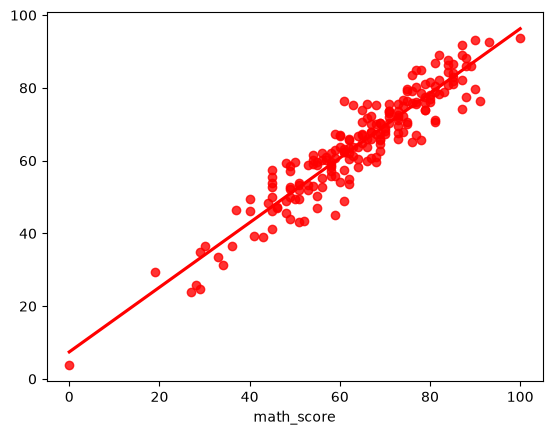

In [64]:
sns.regplot(x=y_test, y=y_pred, ci=None,color='red')

### Difference between Actual and Predicted values

In [65]:
pred_diff = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Difference': y_test - y_pred
})
pred_diff

,Actual Value,Predicted Value,Difference
521,91,76.398705,14.601295
737,53,58.842469,-5.842469
740,80,76.992129,3.007871
660,74,76.805898,-2.805898
411,84,87.615387,-3.615387
...,...,...,...
408,52,43.492293,8.507707
332,62,62.170763,-0.170763
208,74,67.910325,6.089675
613,65,67.061504,-2.061504
